<a href="https://colab.research.google.com/github/dr-bankert-augustana/PHYS_200/blob/main/Lesson_5_1_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a name="Notebook-Start"></a>

---

<font size = 7> <b> Lesson 5.2 (More Update Algorithms) </b> </font>

---

<font size = 5> <b> Notebook Index </b> </font>

1. [Learning Outcomes](#Learning-Outcomes)

2. [Introduction](#Introduction)

3. [Adding Immunization](#Immunization)

4. [Handwashing Campagin and Optimization](#HandWashing)
$
\newcommand{\lsum}{\displaystyle \sum\limits_{i=1}^{N}}
\newcommand{\parens}[1]{\left(#1\right)}
\newcommand{\dsfrac}[2]{\displaystyle\frac{#1}{#2}}
\newcommand{\dpfrac}[2]{\displaystyle\parens{\frac{#1}{#2}}}
\newcommand{\parderiv}[2]{\dsfrac{\partial #1}{\partial #2}}
\newcommand{\spc}{\hspace{0.1 pc}}
\newcommand{\ra}{\Rightarrow}
\newcommand{\of}[1]{{\scriptsize (#1)}}
\newcommand{\rule}{\Huge \hspace{-0.2 pc} \displaystyle\frac{\hspace{20 pc}}{\hspace{20 pc}}}
\newcommand{\mps}{\spc \frac{\textrm{m}}{\textrm{s}}}
\newcommand{\mpss}{\spc \frac{\textrm{m}}{\textrm{s}^2}}
$

<a name="Learning-Outcomes"></a>

---

#<font size = 6> <b> 1. Learning Outcomes </b> </font>

---

<font size = 5> <b> Learning Outcomes: </b> </font>

By the end of this lesson, students will be able to:

  <br>

  1. <b>Explain</b>

[Return to Top](#Notebook-Start)

<a name="Introduction"></a>

---

#<font size = 6> <b> 2. Introduction </b> </font>

---

In [1]:
##=============================================================================================##
## Import Libraries:                                                                           ##
##=============================================================================================##

import time as tm
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display_html

In [2]:
#@title This cell defines the functions: display_dataframes, create_model, display_model, and plot_data

##=============================================================================================##
## Function:  display_dataframes                                                               ##
##                                                                                             ##
## Purpose:   Display multiple DataFrames side-by-side with titles                             ##
##                                                                                             ##
## Input(s):  dataframe_list - List of DataFrames to be displayed                              ##
##            title_list     - List of titles for the displayed DataFrames                     ##
##            n_items        - Number of items to display (optional, default = 5)              ##
##                                                                                             ##
## Output(s): None                                                                             ##
##=============================================================================================##

def display_dataframes(dataframe_list, title_list, n_items = 5, tail = False):

  ##===========================================================================================##
  ## Create a String for Housing the Commands to Be Sent to the display_html() Function:       ##
  ##===========================================================================================##

  html_str = ""

  ##===========================================================================================##
  ## Loop Over the Elements in the item_list and title_list:                                   ##
  ##===========================================================================================##

  for df, title in zip(dataframe_list, title_list):

    # Convert the current dataframe info to html:

    if (tail == True):

      html_df = pd.DataFrame(df).tail(n_items).to_html()

    else:

      html_df = pd.DataFrame(df).head(n_items).to_html()

    ##=========================================================================================##
    ## Wrap title and DataFrames in a Styled HTML <div>:                                       ##
    ##=========================================================================================##

    html_str += "<div style='display: inline-block; margin-right: 20px; vertical-align: top;'>"

    html_str += "<h3 style='text-align: center;'>" + str(title) + "</h3><hr>" + str(html_df)

    html_str += "</div>"

  ##===========================================================================================##
  ## Send the HTML String to the display_html() Function:                                      ##
  ##===========================================================================================##

  display_html(html_str, raw = True)

##=============================================================================================##
## Function:  create_model                                                                     ##
##                                                                                             ##
## Purpose:   Display models' parameters and loss in a DataFrame                               ##
##                                                                                             ##
## Input(s):  model_list - List of models' names to be displayed                               ##
##                                                                                             ##
## Output(s): None                                                                             ##
##=============================================================================================##

def create_model(X, y, name, bias_on = True):

  ##===========================================================================================##
  ## Use a LinearRegression Object to Find the Best Fit for the Model:                         ##
  ##===========================================================================================##

  # Create a LinearRegression object with a forced-origin intercept:

  model = LinearRegression(fit_intercept = bias_on)

  # Fit the LinearRegression objects to the features and target:

  model.fit(X, y)

  # Get the coefficient and bias for the model:

  coefs = np.round(model.coef_[0], 2)
  bias  = np.round(model.intercept_, 2)

  ##===========================================================================================##
  ## Get The Model Predictions:                                                                ##
  ##===========================================================================================##

  predictions = model.predict(X)

  ##===========================================================================================##
  ## Calculate Model Losses:                                                                   ##
  ##===========================================================================================##

  loss = np.sqrt(mean_squared_error(y, predictions))

  ##===========================================================================================##
  ## Create a DataFrame to Store the Model's Results and Predictions:                          ##
  ##===========================================================================================##

  # Create the results DataFrame:

  results_df = pd.DataFrame({"Name": name, "Coefs": [coefs], "Bias": bias, "Loss": loss})

  # Create the predictions DataFrame:

  predictions_df = pd.DataFrame({"Target": X.iloc[:, 0]})

  predictions_df["Predictions"] = predictions

  ##===========================================================================================##
  ## Return the Model's Results and Predictions:                                               ##
  ##===========================================================================================##

  return results_df, predictions_df

##=============================================================================================##
## Function:  display_models                                                                   ##
##                                                                                             ##
## Purpose:   Display models' parameters and loss in a DataFrame                               ##
##                                                                                             ##
## Input(s):  model_list - List of models' names to be displayed                               ##
##            coef_list  - List of models' coefficients to be displayed                        ##
##            bias_list  - List of models' bias to be displayed                                ##
##            loss_list  - List of models' loss to be displayed                                ##
##            title      - Title for the display of models                                     ##
##            trunc      - Number of decimals to display for numbers (optional, default = 3)   ##
##            n_items    - Number of items to display (optional, default = 5)                  ##
##                                                                                             ##
## Output(s): None                                                                             ##
##=============================================================================================##

def display_model(model_list, coef_list, bias_list, loss_list, title, trunc = 3, n_items = 5):

  ##===========================================================================================##
  ## Round the Numeric Values to the Desired Level of Desired Truncation:                      ##
  ##===========================================================================================##

  for i in range (0, len(model_list)):

    coef_list[i] = np.round(coef_list[i], trunc)
    bias_list[i] = np.round(bias_list[i], trunc)
    loss_list[i] = np.round(loss_list[i], trunc)

  ##===========================================================================================##
  ## Create a DataFrame to Hold the Results:                                                   ##
  ##===========================================================================================##

  results = pd.DataFrame()

  ##===========================================================================================##
  ## Add the Contents of the DataFrame Columns:                                                ##
  ##===========================================================================================##

  # Add the model names:

  results["Model"] = model_list

  # Add the model coefficients:

  results["Coefficient(s)"] = coef_list

  # Add the model biases:

  results["Bias"] = bias_list

  # Add the model rmses:

  results["Loss"] = loss_list

  ##===========================================================================================##
  ## Index the Results DataFrame By Model Name:                                                ##
  ##===========================================================================================##

  results.set_index("Model", inplace = True)

  ##===========================================================================================##
  ## Display the Results DataFrame Using display_dataframes():                                 ##
  ##===========================================================================================##

  display_dataframes([results], [title], n_items)

##=============================================================================================##
## Function:  plot_data                                                                        ##
##                                                                                             ##
## Purpose:   Create a scatterplot with optional model overlays and error bands                ##
##                                                                                             ##
## Input(s):  x_data        - List of data points' x-axis values                               ##
##            y_data        - List of data points' y-axis values                               ##
##            title         - Graph title                                                      ##
##            axis_labels   - Override axis labels [x_label, y_label] (optional)               ##
##            model_list    - List of model predictions to overlay (optional)                  ##
##            color_list    - Colors for each model line (optional)                            ##
##            label_list    - Labels for each model line (optional)                            ##
##            error_display - Show +/- error band around first model (default is False)        ##
##            error         - Error value for shaded band (optional)                           ##
##                                                                                             ##
## Output(s): graph       - Matplotlib axes object, can be used for overplotting               ##
##=============================================================================================##

def plot_data(x_data, y_data, title, axis_labels = [], model_list = [], color_list = [],
              label_list = [], error_display = False, error = 0):

  ##===========================================================================================##
  ## Setup the Graph:                                                                          ##
  ##===========================================================================================##

  # Create the Matplotlib figure:

  figure = plt.figure(figsize = (12, 9))

  # Add a graph to the figure:

  graph = figure.add_subplot()

  # Set the graph background Color:

  graph.set_facecolor('lightcyan')

  # Set the graph title:

  graph.set_title(title, fontsize = 20)

  # Set the x_label and y_label:

  if (axis_labels != []):

    graph.set_xlabel(axis_labels[0], fontsize = 14)

    graph.set_ylabel(axis_labels[1], fontsize = 14)

  # Apply a grid to the graph:

  graph.grid(which = 'both')

  # Adjust the x-axis scale of the graph:

  graph.autoscale(enable = True, axis = 'x', tight = False)

  # Adjust the y-axis scale of the graph:

  graph.autoscale(enable = True, axis = 'y', tight = False)

  ##===========================================================================================##
  ## Add Data to the Graph:                                                                    ##
  ##===========================================================================================##

  # Create a scatterplot of the data:

  sns.scatterplot(x = x_data, y = y_data, ax = graph)

  # Overlay model predictions:

  for i in range(0, len(model_list)):

    graph.plot(model_list[i]["Target"], model_list[i]["Predictions"], color = color_list[i],
               label = label_list[i])

  ##===========================================================================================##
  ## If requested, show the +/- error bounds:                                                  ##
  ##===========================================================================================##

  if ((error_display == True) and model_list != []):

    # Create the error+ model:

    model_plus_error  = model_list[-1]["Predictions"] + error

    # Create the error- model:

    model_minus_error = model_list[-1]["Predictions"] - error

    # Store the error+ and error- models in a DataFrame and Sort by x_data values:

    error_df = pd.DataFrame({
        'X-Data': model_list[0]["Target"],
        'Model+Error': model_plus_error,
        'Model-Error': model_minus_error
    }).sort_values(by = "X-Data")

    # Use graph.fill to highlight the region between the error+ and error- models:

    graph.fill_between(error_df['X-Data'], error_df['Model+Error'], error_df['Model-Error'],
                       alpha = 0.5, color = (0.6, 0.6, 0.6), label = "Error Bounds")

  ##===========================================================================================##
  ## Apply the Legend and Return the graph Object:                                             ##
  ##===========================================================================================##

  # Add the graph legend:

  if (label_list != []): graph.legend()

  # Return the graph:

  return graph

## <b>Set the Falling Object Simulation Parameters</b>

In [3]:
#@title This cell defines the simulation parameters for the falling object simulation.

##=============================================================================================##
## Set the Simulation Parameters:                                                              ##
##=============================================================================================##

# Local acceleration due to gravity (in m/s^2):

g = 9.8

# Time step size (in seconds):

dt = 0.01

# Simulation end time (in seconds):

t_end = 10

##=============================================================================================##
## Store the parameters in a Pandas Series:                                                    ##
##=============================================================================================##

parameters_fall = pd.Series({
    "g":  g,
    "dt": dt,
    "t_end": t_end
})

# Rename the columns:

parameters_fall.name = 'Value'

parameters_fall.index.name = "Parameter"

##=============================================================================================##
## Create the State Object                                                                     ##
##=============================================================================================##

# Initial Height:

y_initial = 381.0 # meters

# Initial Velocity:

v_initial = 0 # meters per second

# Initial Time:

t_initial = 0 # seconds

##=============================================================================================##
## Store the initial state in a Pandas Series:                                                 ##
##=============================================================================================##

initial_state_fall = pd.Series({
    "Position" : y_initial,
    "Velocity" : v_initial,
    "Time"     : t_initial
})

initial_state_fall.name = 'Value'

initial_state_fall.index.name = "State"

##=============================================================================================##
## Display the Parameters and Initial State:                                                   ##
##=============================================================================================##

display_dataframes([parameters_fall, initial_state_fall],
                   ["Falling Object Parameters", "Initial State"])

,Value
Parameter,
g,9.80
dt,0.01
t_end,10.00
,Value
State,
Position,381.0
Velocity,0.0
Time,0.0


## <b>Create the Change Euler and Euler-Cromer Method Functions</b>

In [4]:
##=============================================================================================##
## Define the Acceleration Function For the Falling Object Simulation:                         ##
##=============================================================================================##

def acceleration_fall(state, parameters):

  ##===========================================================================================##
  ## Return the Acceleration:                                                                  ##
  ##===========================================================================================##

  return -parameters['g']

In [5]:
#@title This cell defines the Euler and Euler-Cromer DEQ Solver Algorithms.

##=============================================================================================##
## Define the Euler Algorithm Change Function:                                                 ##
##=============================================================================================##

def cf_euler_1d(state, parameters, acceleration):

  ##===========================================================================================##
  ## Prepare the Algorithm Values:                                                             ##
  ##===========================================================================================##

  # Create a local copy of the state object:

  state_local = state.copy()

  # Get the time step size:

  dt = parameters['dt']

  # Get the current position:

  x = state_local['Position']

  # Get the current velocity:

  v = state_local['Velocity']

  # Get the current acceleration:

  a = acceleration(state_local, parameters)

  # Update the position:

  x += v * dt

  # Update the velocity:

  v += a * dt

  ##===========================================================================================##
  ## Update the State:                                                                         ##
  ##===========================================================================================##

  # Update the local state position:

  state_local['Position'] = x

  # Update the local state velocity:

  state_local['Velocity'] = v

  # Update the local state time:

  state_local['Time'] += dt

  ##===========================================================================================##
  ## Return the Updated State:                                                                 ##
  ##===========================================================================================##

  return state_local

##=============================================================================================##
## Define the Euler-Cromer Algorithm Function:                                                 ##
##=============================================================================================##

def cf_euler_cromer_1d(state, parameters, acceleration):

  ##===========================================================================================##
  ## Prepare the Algorithm Values:                                                             ##
  ##===========================================================================================##

  # Create a local copy of the state object:

  state_local = state.copy()

  # Get the time step size:

  dt = parameters['dt']

  # Get the current position:

  x = state_local['Position']

  # Get the current velocity:

  v = state_local['Velocity']

  # Get the current acceleration:

  a = acceleration(state_local, parameters)

  # Update the velocity:

  v += a * dt

  # Update the position:

  x += v * dt

  ##===========================================================================================##
  ## Update the State:                                                                         ##
  ##===========================================================================================##

  # Update the local state position:

  state_local['Position'] = x

  # Update the local state velocity:

  state_local['Velocity'] = v

  # Update the local state time:

  state_local['Time'] += dt

  ##===========================================================================================##
  ## Return the Updated State:                                                                 ##
  ##===========================================================================================##

  return state_local

## <b>Create the Run Simulation Function</b>

In [6]:
#@title This cell defines the run simulation function.

##=============================================================================================##
## Create a Function to Set Up and Run the Simulation:                                         ##
##=============================================================================================##

def run_simulation(parameters, initial_state, change_function, acceleration):

  ##===========================================================================================##
  ## Get the Simulation Start Time:                                                            ##
  ##===========================================================================================##

  start_time = tm.time()

  ##===========================================================================================##
  ## Unpack the Simulation Parameters:                                                         ##
  ##===========================================================================================##

  # Get the end time:

  end_time = parameters.loc['t_end']

  # Get the step size:

  dt = parameters.loc['dt']

  # Calculate the number of simulation steps:

  n_steps = int(end_time / dt)

  ##===========================================================================================##
  ## Create a Copy of the Initial State:                                                       ##
  ##===========================================================================================##

  state = initial_state.copy()

  ##===========================================================================================##
  ## Create the System's State History:                                                        ##
  ##===========================================================================================##

  # Create the state_history DataFrame:

  state_history = pd.DataFrame()

  state_history.name = 'Motion Over Time'

  state_history.index.name = 'Time Step'

  # Set the first entry in the state_history to be the initial system state:

  state_history[0] = state

  state_history = state_history.T

  ##===========================================================================================##
  ## Run the Simulation for the Desired Number of Time Steps:                                  ##
  ##===========================================================================================##

  for i in range(n_steps):

    # Get the state of the system for the current time step:

    state = change_function(state, parameters, acceleration)

    # Store the new system state in the state_history DataFrame:

    state_history.loc[i + 1] = state.T

    # If an end condition has been reached, break the loop:

    #if (end_condition == True): break

  ##===========================================================================================##
  ## Get the Simulation End Time:                                                              ##
  ##===========================================================================================##

  end_time = tm.time()

  print("Elapsed Simulation Runtime:", np.round(end_time - start_time, 5), "seconds")

  ##===========================================================================================##
  ## Return the System's State History:                                                        ##
  ##===========================================================================================##

  return state_history

## <b>Create the Analyze Simulation Function</b>

In [7]:
#@title This cell defines the loss function for the falling object simulation.

##=============================================================================================##
## Create a Function to Calculate Loss:                                                        ##
##=============================================================================================##

def loss_falling_object(parameters, state_history):

  ##===========================================================================================##
  ## Calculate the Initial Total Energy:                                                       ##
  ##===========================================================================================##

  total_energy_initial = parameters['g'] * state_history.iloc[0]['Position']

  ##===========================================================================================##
  ## Calculate the Total Energy History:                                                       ##
  ##===========================================================================================##

  total_energy_history = parameters['g'] * state_history.iloc[:]['Position'] + \
                         0.5 * state_history.iloc[:]['Velocity'] ** 2

  ##===========================================================================================##
  ## Calculate the Loss History:                                                               ##
  ##===========================================================================================##

  loss_history = (total_energy_history - total_energy_initial) / total_energy_initial

  ##===========================================================================================##
  ## Return the Loss History:                                                                  ##
  ##===========================================================================================##

  return loss_history

In [8]:
#@title This cell defines the analyze simulation function.

##=============================================================================================##
## Create a Function to Analyze the Simulation Results:                                        ##
##=============================================================================================##

def analyze_simulation(state_history, parameters, loss_function, x_list = [], y_list = [],
                       color_list = [], title_list = [], x_label_list = [], y_label_list = [],
                       aspect_list = [], plot_data = False, display_data = False):

  ##===========================================================================================##
  ## Compute the Simulation_Loss:                                                              ##
  ##===========================================================================================##

  loss_history = loss_function(parameters, state_history)

  ##===========================================================================================##
  ## Add the Loss History to the State History:                                                ##
  ##===========================================================================================##

  state_history['Loss'] = loss_history

  ##===========================================================================================##
  ## Calculate the Total Loss:                                                                 ##
  ##===========================================================================================##

  total_loss = loss_history.sum()

  ##===========================================================================================##
  ## If requested, display the history data:                                                   ##
  ##===========================================================================================##

  if (display_data == True):

    # View the system's state history and final state:

    display_dataframes([state_history, state_history.iloc[-1]],["State History", "Final State"],
                       n_items = 7)

  ##===========================================================================================##
  ## If requested, plot the history data:                                                      ##
  ##===========================================================================================##

  if (plot_data == True):

    # Get the settings for each graph to be made:

    for X, Y, color, title, x_label, y_label, aspect in \
      zip(x_list, y_list, color_list, title_list, x_label_list, y_label_list, aspect_list):

      # Create the graph:

      x_size = 10
      y_size = 10 * aspect

      ax = state_history.plot(
        kind    = 'line',
        y       = [Y],
        x       = str(X),
        color   = [color],
        figsize = (x_size, y_size)
      )

      # Set the graph title:

      ax.set_title(title, fontsize = 14)

      # Set the Graph x-axis label:

      ax.set_xlabel(x_label, fontsize = 12)

      # Set the Graph y-axis label:

      ax.set_ylabel(y_label, fontsize = 12)

      # Add grid and suppress the legend:

      ax.grid(True, linestyle = '--', alpha = 0.5)

      legend = ax.legend()

      legend.remove()

    # Display the plots:

    plt.show()

  ##===========================================================================================##
  ## Return the History Data:                                                                  ##
  ##===========================================================================================##

  return state_history.iloc[-1]['Loss']

## <b>Test the Euler Algorithm</b>

Elapsed Simulation Runtime: 1.30851 seconds


State History 
 
 
 Time Step 
 Position 
 Velocity 
 Time 
 Loss 
 
 
 
 
 0 
 381.00000 
 0.000 
 0.00 
 0.000000 
 
 
 1 
 381.00000 
 -0.098 
 0.01 
 0.000001 
 
 
 2 
 380.99902 
 -0.196 
 0.02 
 0.000003 
 
 
 3 
 380.99706 
 -0.294 
 0.03 
 0.000004 
 
 
 4 
 380.99412 
 -0.392 
 0.04 
 0.000005 
 
 
 5 
 380.99020 
 -0.490 
 0.05 
 0.000006 
 
 
 6 
 380.98530 
 -0.588 
 0.06 
 0.000008 
 
 
 Final State 
 
 
 
 883 
 
 
 Time Step 
 
 
 
 
 
 Position 
 -0.614940 
 
 
 Velocity 
 -86.534000 
 
 
 Time 
 8.830000 
 
 
 Loss 
 0.001136

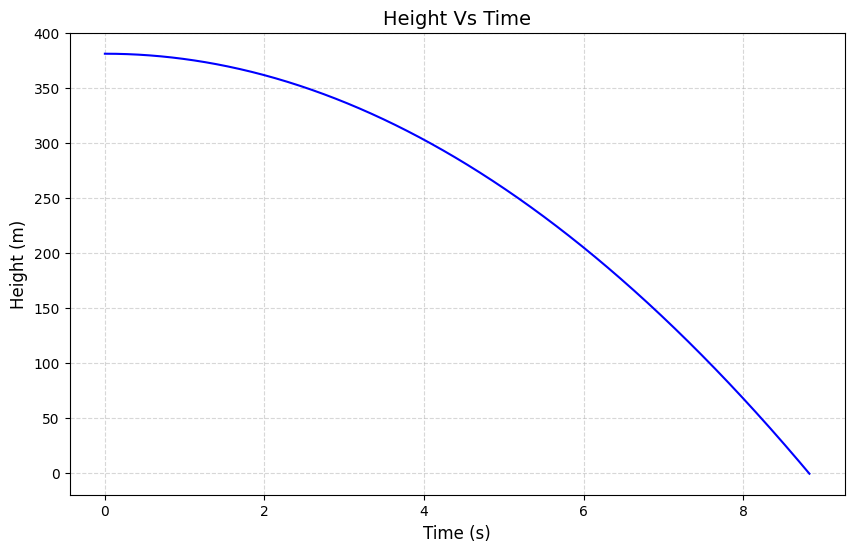

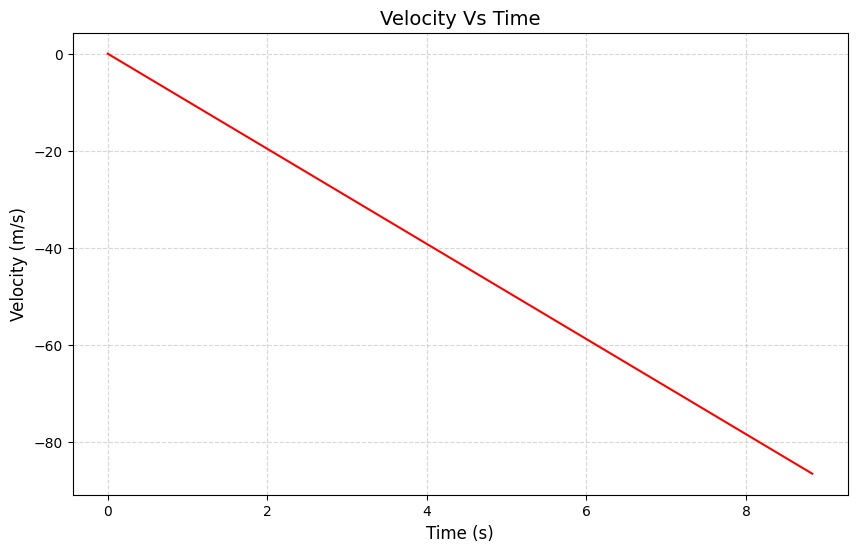

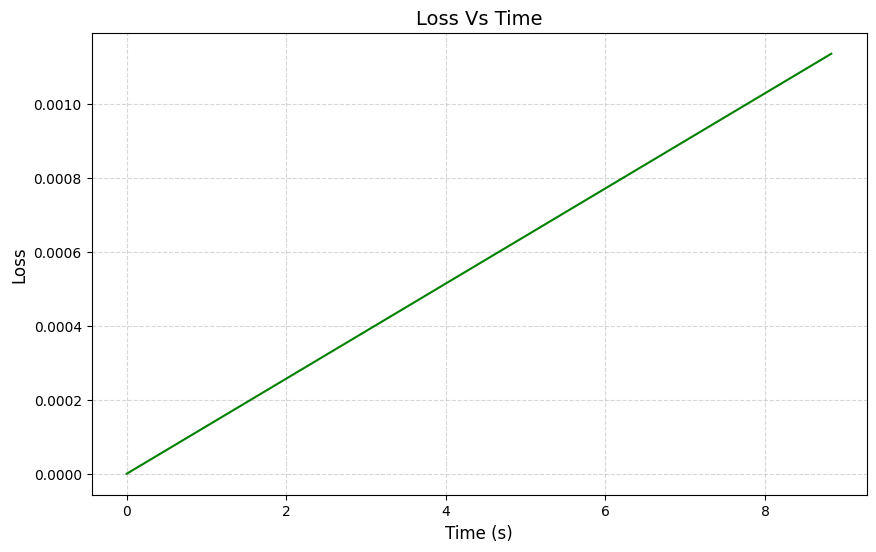

In [9]:
##=============================================================================================##
## Run the Simulation and Get the Sate History:                                                ##
##=============================================================================================##

# Set the time step:

parameters_fall['dt'] = 1E-2
parameters_fall['t_end'] = 8.83

history_fall = run_simulation(parameters_fall, initial_state_fall, cf_euler_1d,
                              acceleration_fall)

##=============================================================================================##
## Analyze the Sate History and Get the Simulion Loss:                                         ##
##=============================================================================================##

y_list   = ['Position', 'Velocity', 'Loss']
x_list   = ['Time', 'Time', 'Time']
colors   = ['blue', 'red', 'green']
titles   = ['Height Vs Time', 'Velocity Vs Time', 'Loss Vs Time']
y_labels = ['Height (m)', 'Velocity (m/s)', 'Loss']
x_labels = ['Time (s)', 'Time (s)', 'Time (s)']
aspects  = [0.6, 0.6, 0.6]

loss = analyze_simulation(history_fall, parameters_fall, loss_falling_object,
                          x_list, y_list, colors, titles, x_labels, y_labels, aspects,
                          plot_data = True, display_data = True)

## <b>Test the Euler-Cromer Algorithm</b>

Elapsed Simulation Runtime: 0.74123 seconds


State History 
 
 
 Time Step 
 Position 
 Velocity 
 Time 
 Loss 
 
 
 
 
 0 
 381.00000 
 0.000 
 0.00 
 0.000000 
 
 
 1 
 380.99902 
 -0.098 
 0.01 
 -0.000001 
 
 
 2 
 380.99706 
 -0.196 
 0.02 
 -0.000003 
 
 
 3 
 380.99412 
 -0.294 
 0.03 
 -0.000004 
 
 
 4 
 380.99020 
 -0.392 
 0.04 
 -0.000005 
 
 
 5 
 380.98530 
 -0.490 
 0.05 
 -0.000006 
 
 
 6 
 380.97942 
 -0.588 
 0.06 
 -0.000008 
 
 
 Final State 
 
 
 
 882 
 
 
 Time Step 
 
 
 
 
 
 Position 
 -0.614940 
 
 
 Velocity 
 -86.436000 
 
 
 Time 
 8.820000 
 
 
 Loss 
 -0.001134

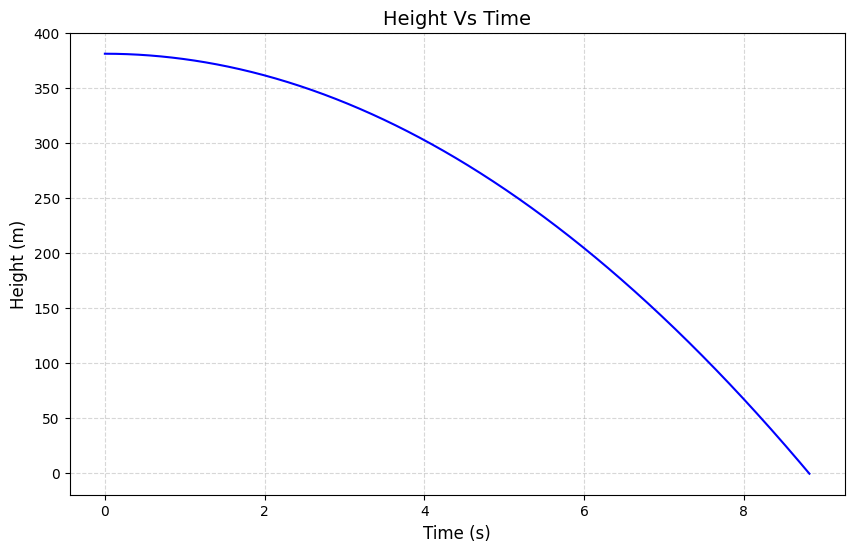

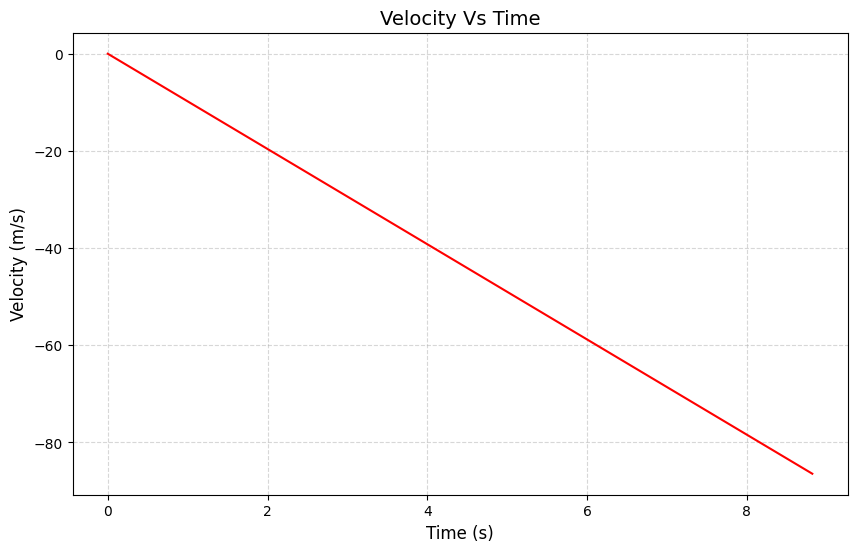

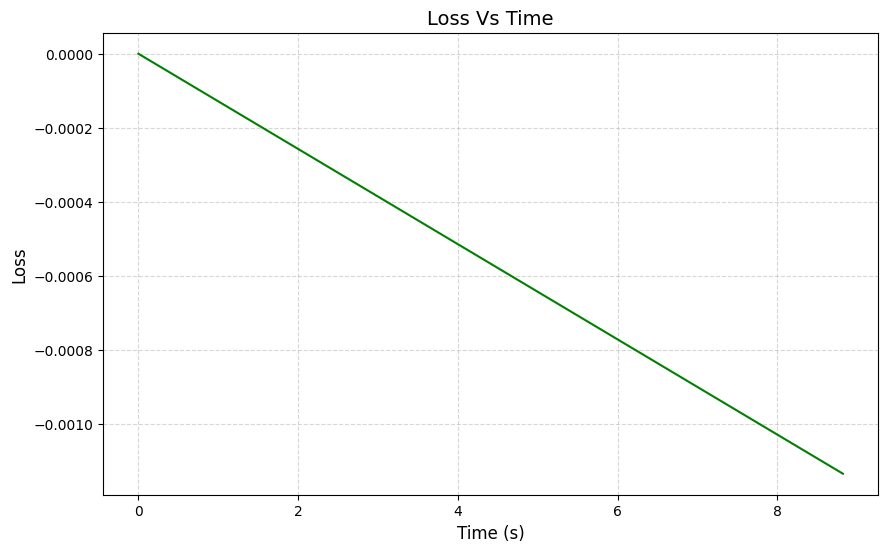

In [10]:
##=============================================================================================##
## Run the Simulation and Get the Sate History:                                                ##
##=============================================================================================##

# Set the time step:

parameters_fall['dt'] = 1E-2
parameters_fall['t_end'] = 8.82

history_fall = run_simulation(parameters_fall, initial_state_fall, cf_euler_cromer_1d,
                              acceleration_fall)

##=============================================================================================##
## Analyze the Sate History and Get the Simulion Loss:                                         ##
##=============================================================================================##

y_list   = ['Position', 'Velocity', 'Loss']
x_list   = ['Time', 'Time', 'Time']
colors   = ['blue', 'red', 'green']
titles   = ['Height Vs Time', 'Velocity Vs Time', 'Loss Vs Time']
y_labels = ['Height (m)', 'Velocity (m/s)', 'Loss']
x_labels = ['Time (s)', 'Time (s)', 'Time (s)']
aspects  = [0.6, 0.6, 0.6]

loss = analyze_simulation(history_fall, parameters_fall, loss_falling_object,
                          x_list, y_list, colors, titles, x_labels, y_labels, aspects,
                          plot_data = True, display_data = True)

## <b>Create the Euler-Richardson Method Function</b>

In [11]:
##=============================================================================================##
## Define the Euler Algorithm Function:                                                        ##
##=============================================================================================##

def cf_euler_richardson_1d(state, parameters, acceleration):

  ##===========================================================================================##
  ## Prepare the Algorithm Values:                                                             ##
  ##===========================================================================================##

  # Create a local copy of the state object:

  state_local = state.copy()

  # Get the time step size:

  dt = parameters['dt']

  # Get the current position:

  x = state_local['Position']

  # Get the current velocity:

  v = state_local['Velocity']

  # Get the current acceleration:

  a = acceleration(state_local, parameters)

  ##===========================================================================================##
  ## Get the Midpoint Values:                                                                  ##
  ##===========================================================================================##

  # Calculate the midpoint velocity:

  v_mid = v + a * dt / 2

  # Calculate the midpoint position:

  x_mid = x + v * dt / 2

  # Update the local state:

  state_local['Position'] = x_mid

  state_local['Velocity'] = v_mid

  # Calculate the midpoint acceleration:

  a_mid = acceleration(state_local, parameters)

  ##===========================================================================================##
  ## Calculate the Updated Values:                                                             ##
  ##===========================================================================================##

  # Update the position:

  x += v_mid * dt

  # Update the velocity:

  v += a_mid * dt

  ##===========================================================================================##
  ## Update the State:                                                                         ##
  ##===========================================================================================##

  # Update the local state position:

  state_local['Position'] = x

  # Update the local state velocity:

  state_local['Velocity'] = v

  # Update the local state time:

  state_local['Time'] += dt

  ##===========================================================================================##
  ## Return the Updated State:                                                                 ##
  ##===========================================================================================##

  return state_local

## <b>Test the Euler-Richardson Method</b>

Elapsed Simulation Runtime: 0.75412 seconds


State History 
 
 
 Time Step 
 Position 
 Velocity 
 Time 
 Loss 
 
 
 
 
 0 
 381.00000 
 0.000 
 0.00 
 0.000000e+00 
 
 
 1 
 380.99951 
 -0.098 
 0.01 
 0.000000e+00 
 
 
 2 
 380.99804 
 -0.196 
 0.02 
 1.217921e-16 
 
 
 3 
 380.99559 
 -0.294 
 0.03 
 0.000000e+00 
 
 
 4 
 380.99216 
 -0.392 
 0.04 
 1.217921e-16 
 
 
 5 
 380.98775 
 -0.490 
 0.05 
 0.000000e+00 
 
 
 6 
 380.98236 
 -0.588 
 0.06 
 1.217921e-16 
 
 
 Final State 
 
 
 
 881 
 
 
 Time Step 
 
 
 
 
 
 Position 
 6.811100e-01 
 
 
 Velocity 
 -8.633800e+01 
 
 
 Time 
 8.810000e+00 
 
 
 Loss 
 -1.023054e-14

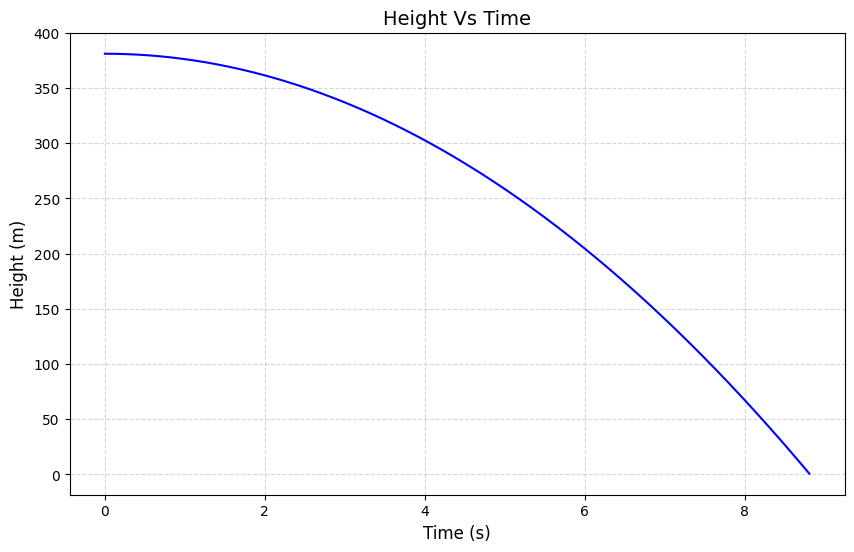

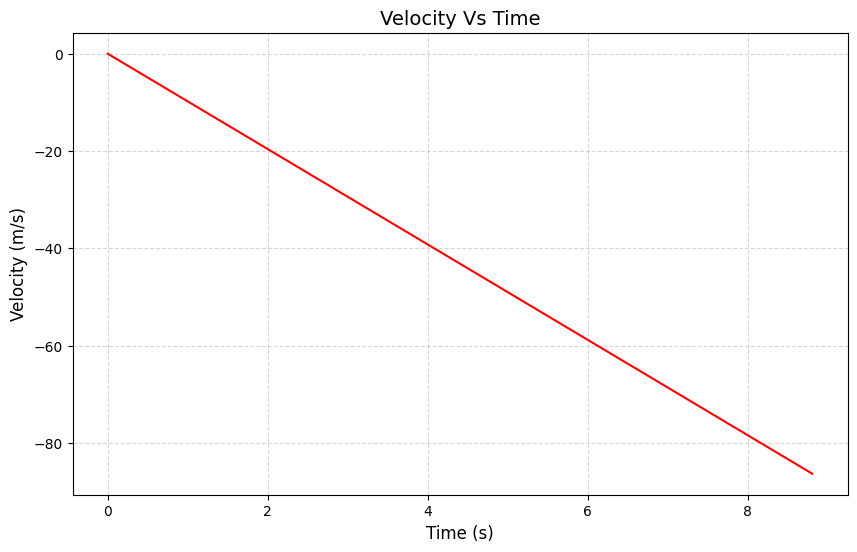

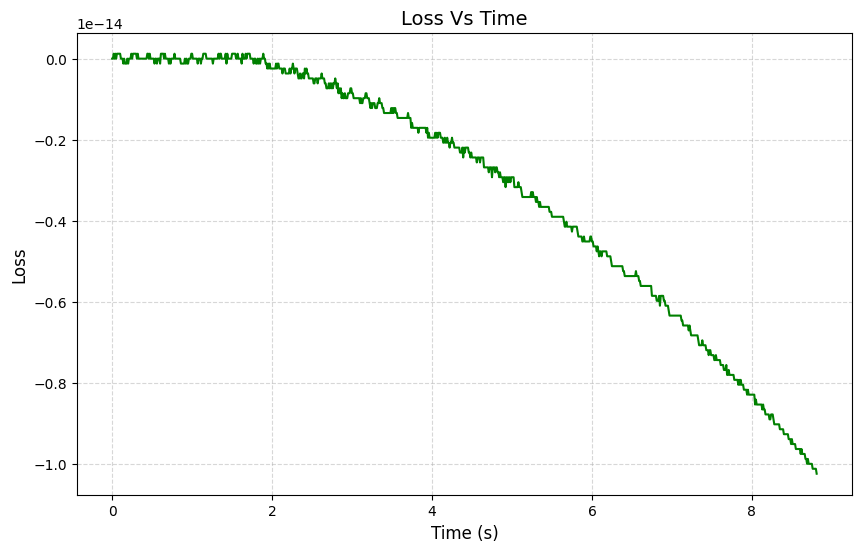

In [12]:
##=============================================================================================##
## Run the Simulation and Get the Sate History:                                                ##
##=============================================================================================##

# Set the time step:

parameters_fall['dt'] = 1E-2
parameters_fall['t_end'] = 8.81

history_fall = run_simulation(parameters_fall, initial_state_fall, cf_euler_richardson_1d,
                              acceleration_fall)

##=============================================================================================##
## Analyze the Sate History and Get the Simulion Loss:                                         ##
##=============================================================================================##

y_list   = ['Position', 'Velocity', 'Loss']
x_list   = ['Time', 'Time', 'Time']
colors   = ['blue', 'red', 'green']
titles   = ['Height Vs Time', 'Velocity Vs Time', 'Loss Vs Time']
y_labels = ['Height (m)', 'Velocity (m/s)', 'Loss']
x_labels = ['Time (s)', 'Time (s)', 'Time (s)']
aspects  = [0.6, 0.6, 0.6]

loss = analyze_simulation(history_fall, parameters_fall, loss_falling_object,
                          x_list, y_list, colors, titles, x_labels, y_labels, aspects,
                          plot_data = True, display_data = True)

[Return to Top](#Notebook-Start)

<a name="Introduction"></a>

---

#<font size = 6> <b> 3. Orbits </b> </font>

---

## <b>Create the Simulation Parameters</b>

In [13]:
##=============================================================================================##
## Set the Simulation Parameters:                                                              ##
##=============================================================================================##

# Universal gravitational constant (in N m^2/kg^2):

G = 6.67408e-11

# Mass of the Sun (in kilograms):

M = 1.989e30

# Time step size (in seconds):

dt = 1E5

# Simulation end time (in seconds):

t_end = 2E8

##=============================================================================================##
## Store the parameters in a Pandas Series:                                                    ##
##=============================================================================================##

parameters_orbit = pd.Series({
    "G"    : G,
    "M"    : M,
    "dt"   : dt,
    "t_end": t_end
})

# Rename the columns:

parameters_orbit.name = 'Value'

parameters_orbit.index.name = "Parameter"

##=============================================================================================##
## Create the State Object                                                                     ##
##=============================================================================================##

# Initial Position:

x_initial = 149_597_870_700.0  # meters

y_initial = 0.0 # meters

# Initial Velocity:

vx = 0.0 # meters per second

vy = np.sqrt(G * M / x_initial) #29_780.0 # meters per second

# Initial Time:

t_initial = 0.0 # seconds

##=============================================================================================##
## Store the initial state in a Pandas Series:                                                 ##
##=============================================================================================##

initial_state_orbit = pd.Series({
    "X_Position": x_initial,
    "Y_Position": y_initial,
    "X_Velocity": vx,
    "Y_Velocity": vy,
    "Time"     : t_initial
})

initial_state_orbit.name = 'Value'

initial_state_orbit.index.name = "State"

##=============================================================================================##
## Display the Parameters and Initial State:                                                   ##
##=============================================================================================##

display_dataframes([parameters_orbit, initial_state_orbit],["Parameters", "Initial State"],
                   n_items = 10)

,Value
Parameter,
G,6.674080e-11
M,1.989000e+30
dt,1.000000e+05
t_end,2.000000e+08
,Value
State,
X_Position,1.495979e+11
Y_Position,0.000000e+00
X_Velocity,0.000000e+00


## <b>Create the Orbital Euler Method Function</b>

In [14]:
##=============================================================================================##
## Define the Acceleration Function For the Falling Object Simulation:                         ##
##=============================================================================================##

def acceleration_orbit(state, parameters):

  ##===========================================================================================##
  ## Unpack the Parameters:                                                                    ##
  ##===========================================================================================##

  G = parameters['G']

  M = parameters['M']

  ##===========================================================================================##
  ## Unpack the State:                                                                          ##
  ##===========================================================================================##

  x = state['X_Position']

  y = state['Y_Position']

  ##===========================================================================================##
  ## Compute the Acceleration:                                                                  ##
  ##===========================================================================================##

  r = np.sqrt(x**2 + y**2)

  ax = -G * M * x / r**3

  ay = -G * M * y / r**3

  ##===========================================================================================##
  ## Return the Acceleration:                                                                   ##
  ##===========================================================================================##

  return ax, ay

In [15]:
##=============================================================================================##
## Define the Euler Algorithm Change Function:                                                 ##
##=============================================================================================##

def cf_euler_2d(state, parameters, acceleration):

  ##===========================================================================================##
  ## Prepare the Algorithm Values:                                                             ##
  ##===========================================================================================##

  # Create a local copy of the state object:

  state_local = state.copy()

  # Get the time step size:

  dt = parameters['dt']

  # Get the current position:

  x = state_local['X_Position']

  y = state_local['Y_Position']

  # Get the current velocity:

  vx = state_local['X_Velocity']

  vy = state_local['Y_Velocity']

  # Get the current acceleration:

  ax, ay = acceleration(state_local, parameters)

  # Update the position:

  x += vx * dt

  y += vy * dt

  # Update the velocity:

  vx += ax * dt

  vy += ay * dt

  ##===========================================================================================##
  ## Update the State:                                                                         ##
  ##===========================================================================================##

  # Update the local state position:

  state_local['X_Position'] = x

  state_local['Y_Position'] = y

  # Update the local state velocity:

  state_local['X_Velocity'] = vx

  state_local['Y_Velocity'] = vy

  # Update the local state time:

  state_local['Time'] += dt

  ##===========================================================================================##
  ## Return the Updated State:                                                                 ##
  ##===========================================================================================##

  return state_local

##=============================================================================================##
## Define the Euler Algorithm Change Function:                                                 ##
##=============================================================================================##

def cf_euler_cromer_2d(state, parameters, acceleration):

  ##===========================================================================================##
  ## Prepare the Algorithm Values:                                                             ##
  ##===========================================================================================##

  # Create a local copy of the state object:

  state_local = state.copy()

  # Get the time step size:

  dt = parameters['dt']

  # Get the current position:

  x = state_local['X_Position']

  y = state_local['Y_Position']

  # Get the current velocity:

  vx = state_local['X_Velocity']

  vy = state_local['Y_Velocity']

  # Get the current acceleration:

  ax, ay = acceleration(state_local, parameters)

  # Update the velocity:

  vx += ax * dt

  vy += ay * dt

  # Update the position:

  x += vx * dt

  y += vy * dt

  ##===========================================================================================##
  ## Update the State:                                                                         ##
  ##===========================================================================================##

  # Update the local state position:

  state_local['X_Position'] = x

  state_local['Y_Position'] = y

  # Update the local state velocity:

  state_local['X_Velocity'] = vx

  state_local['Y_Velocity'] = vy

  # Update the local state time:

  state_local['Time'] += dt

  ##===========================================================================================##
  ## Return the Updated State:                                                                 ##
  ##===========================================================================================##

  return state_local

##=============================================================================================##
## Define the Euler Algorithm Function:                                                        ##
##=============================================================================================##

def cf_euler_richardson_2d(state, parameters, acceleration):

  ##===========================================================================================##
  ## Prepare the Algorithm Values:                                                             ##
  ##===========================================================================================##

  # Create a local copy of the state object:

  state_local = state.copy()

  # Get the time step size:

  dt = parameters['dt']

  # Get the current position:

  x = state_local['X_Position']

  y = state_local['Y_Position']

  # Get the current velocity:

  vx = state_local['X_Velocity']

  vy = state_local['Y_Velocity']

  # Get the current acceleration:

  ax, ay = acceleration(state_local, parameters)

  ##===========================================================================================##
  ## Get the Midpoint Values:                                                                  ##
  ##===========================================================================================##

  # Calculate the midpoint velocity:

  vx_mid = vx + ax * dt / 2

  vy_mid = vy + ay * dt / 2

  # Calculate the midpoint position:

  x_mid = x + vx * dt / 2

  y_mid = y + vy * dt / 2

  # Update the local state:

  state_local['X_Position'] = x_mid

  state_local['Y_Position'] = y_mid

  state_local['X_Velocity'] = vx_mid

  state_local['Y_Velocity'] = vy_mid

  # Calculate the midpoint acceleration:

  ax_mid, ay_mid = acceleration(state_local, parameters)

  ##===========================================================================================##
  ## Calculate the Updated Values:                                                             ##
  ##===========================================================================================##

  # Update the position:

  x += vx_mid * dt

  y += vy_mid * dt

  # Update the velocity:

  vx += ax_mid * dt

  vy += ay_mid * dt

  ##===========================================================================================##
  ## Update the State:                                                                         ##
  ##===========================================================================================##

  # Update the local state position:

  state_local['X_Position'] = x

  state_local['Y_Position'] = y

  # Update the local state velocity:

  state_local['X_Velocity'] = vx

  state_local['Y_Velocity'] = vy

  # Update the local state time:

  state_local['Time'] += dt

  ##===========================================================================================##
  ## Return the Updated State:                                                                 ##
  ##===========================================================================================##

  return state_local

## <b>Create the Analyze Orbit Simulation Function</b>

In [24]:
##=============================================================================================##
## Create a Function to Calculate Loss:                                                        ##
##=============================================================================================##

def loss_orbit_history(parameters, state_history):

  ##===========================================================================================##
  ## Calculate the Initial Total Energy:                                                       ##
  ##===========================================================================================##

  potential_energy_initial = - parameters['G'] * parameters['M'] / \
    np.sqrt(state_history.iloc[0]['X_Position']**2 + state_history.iloc[0]['Y_Position']**2)

  kinetic_energy_initial = 0.5 * state_history.iloc[0]['X_Velocity']**2 + \
    0.5 * state_history.iloc[0]['Y_Velocity']**2

  total_energy_initial = potential_energy_initial + kinetic_energy_initial

  ##===========================================================================================##
  ## Calculate the Total Energy History:                                                       ##
  ##===========================================================================================##

  potential_energy_history = - parameters['G'] * parameters['M'] / \
    np.sqrt(state_history.iloc[:]['X_Position']**2 + state_history.iloc[:]['Y_Position']**2)

  kinetic_energy_history = 0.5 * state_history.iloc[:]['X_Velocity']**2 + \
    0.5 * state_history.iloc[:]['Y_Velocity']**2

  total_energy_history = potential_energy_history + kinetic_energy_history

  ##===========================================================================================##
  ## Calculate the Loss History:                                                               ##
  ##===========================================================================================##

  loss_history = (total_energy_history - total_energy_initial) / total_energy_initial

  ##===========================================================================================##
  ## Return the Loss History:                                                                  ##
  ##===========================================================================================##

  return loss_history

In [31]:
##=============================================================================================##
## Create a Function to Calculate Loss:                                                        ##
##=============================================================================================##

def loss_orbit(parameters, state_1, state_2):

  ##===========================================================================================##
  ## Calculate the Initial Total Energy:                                                       ##
  ##===========================================================================================##

  potential_energy_initial = - parameters['G'] * parameters['M'] / \
    np.sqrt(state_1['X_Position']**2 + state_1['Y_Position']**2)

  kinetic_energy_initial = 0.5 * state_1['X_Velocity']**2 + \
    0.5 * state_1['Y_Velocity']**2

  total_energy_initial = potential_energy_initial + kinetic_energy_initial

  ##===========================================================================================##
  ## Calculate the Total Energy History:                                                       ##
  ##===========================================================================================##

  potential_energy_step = - parameters['G'] * parameters['M'] / \
    np.sqrt(state_2['X_Position']**2 + state_2['Y_Position']**2)

  kinetic_energy_step = 0.5 * state_2['X_Velocity']**2 + \
    0.5 * state_2['Y_Velocity']**2

  total_energy_step = potential_energy_step + kinetic_energy_step

  ##===========================================================================================##
  ## Calculate the Loss History:                                                               ##
  ##===========================================================================================##

  loss_history = (total_energy_step - total_energy_initial) / total_energy_initial

  ##===========================================================================================##
  ## Return the Loss History:                                                                  ##
  ##===========================================================================================##

  return loss_history

## <b>Test the Orbital Simulation Using the Euler Algorithm</b>

Elapsed Simulation Runtime: 1.68965 seconds


State History 
 
 
 Time Step 
 X_Position 
 Y_Position 
 X_Velocity 
 Y_Velocity 
 Time 
 Loss 
 
 
 
 
 0 
 1.495979e+11 
 0.000000e+00 
 0.000000 
 29788.620358 
 0.0 
 -0.000000 
 
 
 1 
 1.495979e+11 
 2.978862e+09 
 -593.164795 
 29788.620358 
 100000.0 
 -0.000793 
 
 
 2 
 1.495386e+11 
 5.957724e+09 
 -1185.976974 
 29776.816007 
 200000.0 
 -0.001585 
 
 
 3 
 1.494200e+11 
 8.935406e+09 
 -1778.201834 
 29753.221341 
 300000.0 
 -0.002378 
 
 
 4 
 1.492421e+11 
 1.191073e+10 
 -2369.604810 
 29717.855077 
 400000.0 
 -0.003169 
 
 
 5 
 1.490052e+11 
 1.488251e+10 
 -2959.951576 
 29670.740638 
 500000.0 
 -0.003961 
 
 
 6 
 1.487092e+11 
 1.784959e+10 
 -3549.008139 
 29611.906157 
 600000.0 
 -0.004751 
 
 
 Final State 
 
 
 
 2000 
 
 
 Time Step 
 
 
 
 
 
 X_Position 
 -4.905691e+10 
 
 
 Y_Position 
 -2.766639e+11 
 
 
 X_Velocity 
 2.083734e+04 
 
 
 Y_Velocity 
 -4.089135e+03 
 
 
 Time 
 2.000000e+08 
 
 
 Loss 
 -4.433220e-01

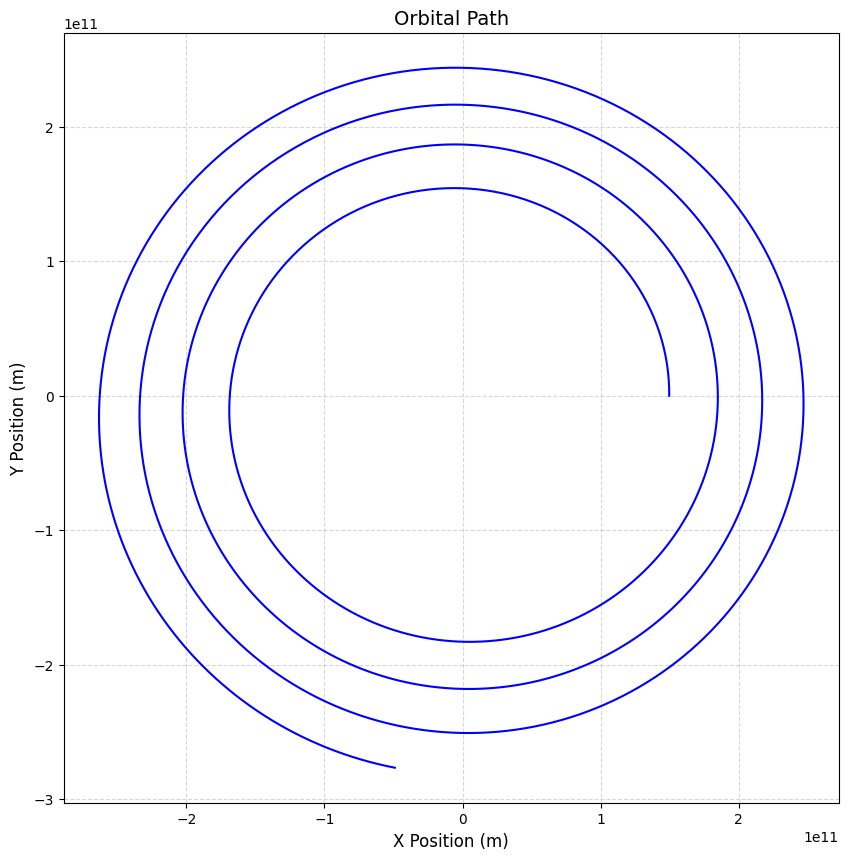

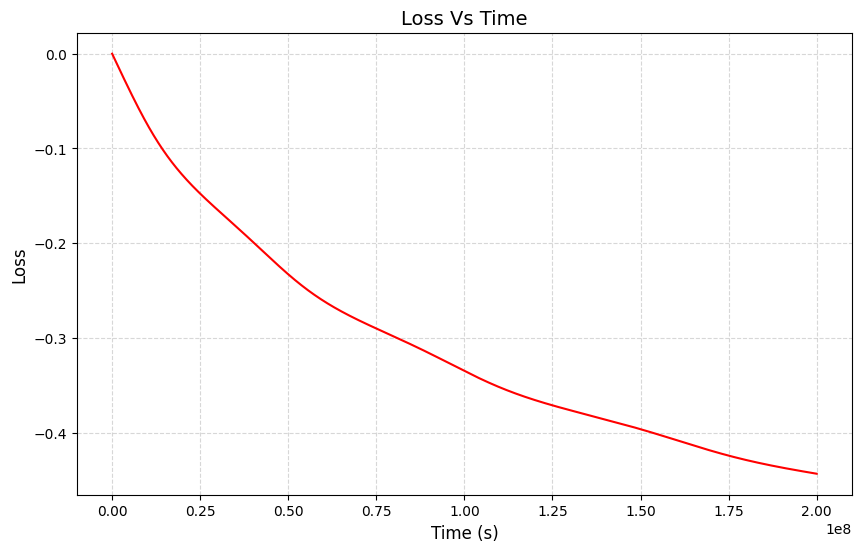

In [17]:
##=============================================================================================##
## Run the Simulation and Get the Sate History:                                                ##
##=============================================================================================##

# Set the time step:

parameters_fall['dt'] = 1E5

history_orbit = run_simulation(parameters_orbit, initial_state_orbit, cf_euler_2d, acceleration_orbit)

##=============================================================================================##
## Analyze the Sate History and Get the Simulion Loss:                                         ##
##=============================================================================================##

y_list   = ['Y_Position', 'Loss']
x_list   = ['X_Position', 'Time']
colors   = ['blue', 'red',]
titles   = ['Orbital Path', 'Loss Vs Time']
y_labels = ['Y Position (m)', 'Loss']
x_labels = ['X Position (m)', 'Time (s)']
aspects  = [1.0, 0.6]

loss = analyze_simulation(history_orbit, parameters_orbit, loss_orbit,
                          x_list, y_list, colors, titles, x_labels, y_labels, aspects,
                          plot_data = True, display_data = True)

## <b>Test the Orbital Simulation Using the Euler-Cromer Algorithm</b>

Elapsed Simulation Runtime: 1.72978 seconds


State History 
 
 
 Time Step 
 X_Position 
 Y_Position 
 X_Velocity 
 Y_Velocity 
 Time 
 Loss 
 
 
 
 
 0 
 1.495979e+11 
 0.000000e+00 
 0.000000 
 29788.620358 
 0.0 
 -0.000000e+00 
 
 
 1 
 1.495386e+11 
 2.978862e+09 
 -593.164795 
 29788.620358 
 100000.0 
 -3.935885e-08 
 
 
 2 
 1.494199e+11 
 5.956542e+09 
 -1186.447081 
 29776.801960 
 200000.0 
 -1.575446e-07 
 
 
 3 
 1.492419e+11 
 8.931858e+09 
 -1779.611130 
 29753.155803 
 300000.0 
 -3.546974e-07 
 
 
 4 
 1.490047e+11 
 1.190363e+10 
 -2372.420696 
 29717.677234 
 400000.0 
 -6.309261e-07 
 
 
 5 
 1.487082e+11 
 1.487066e+10 
 -2964.639117 
 29670.366337 
 500000.0 
 -9.863072e-07 
 
 
 6 
 1.483526e+11 
 1.783178e+10 
 -3556.029407 
 29611.227952 
 600000.0 
 -1.420885e-06 
 
 
 Final State 
 
 
 
 2000 
 
 
 Time Step 
 
 
 
 
 
 X_Position 
 -8.066251e+10 
 
 
 Y_Position 
 1.245449e+11 
 
 
 X_Velocity 
 -2.546070e+04 
 
 
 Y_Velocity 
 -1.593448e+04 
 
 
 Time 
 2.000000e+08 
 
 
 Loss 
 -3.117631e-04

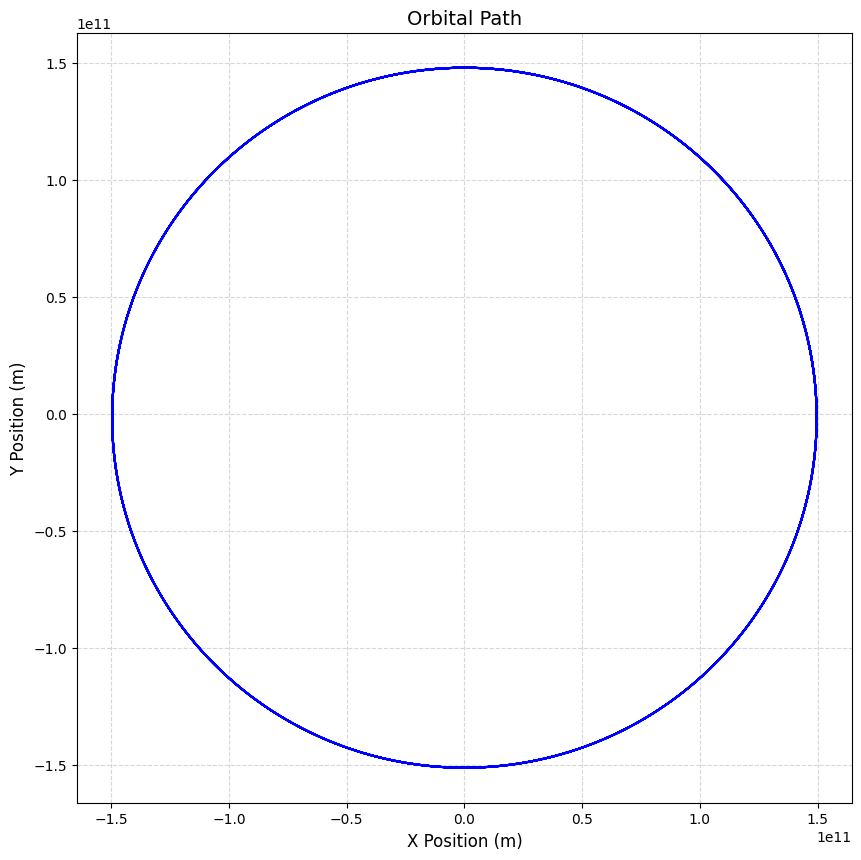

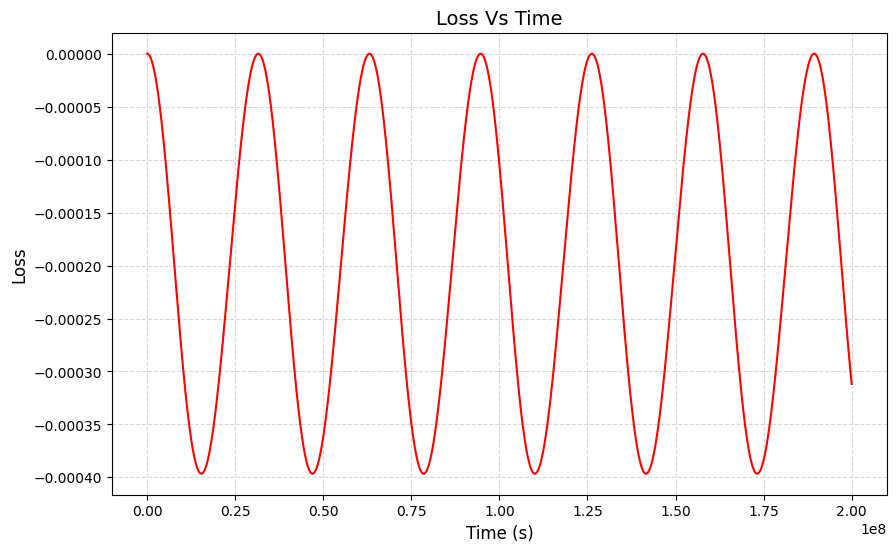

In [18]:
##=============================================================================================##
## Run the Simulation and Get the Sate History:                                                ##
##=============================================================================================##

# Set the time step:

parameters_orbit['dt'] = 1E5

history_orbit = run_simulation(parameters_orbit, initial_state_orbit, cf_euler_cromer_2d, acceleration_orbit)

##=============================================================================================##
## Analyze the Sate History and Get the Simulion Loss:                                         ##
##=============================================================================================##

y_list   = ['Y_Position', 'Loss']
x_list   = ['X_Position', 'Time']
colors   = ['blue', 'red',]
titles   = ['Orbital Path', 'Loss Vs Time']
y_labels = ['Y Position (m)', 'Loss']
x_labels = ['X Position (m)', 'Time (s)']
aspects  = [1.0, 0.6]

loss = analyze_simulation(history_orbit, parameters_orbit, loss_orbit,
                          x_list, y_list, colors, titles, x_labels, y_labels, aspects,
                          plot_data = True, display_data = True)

## <b>Test the Orbital Simulation Using the Euler-Richardson Algorithm</b>

Elapsed Simulation Runtime: 1.86867 seconds


State History 
 
 
 Time Step 
 X_Position 
 Y_Position 
 X_Velocity 
 Y_Velocity 
 Time 
 Loss 
 
 
 
 
 0 
 1.495979e+11 
 0.000000e+00 
 0.000000 
 29788.620358 
 0.0 
 -0.000000e+00 
 
 
 1 
 1.495682e+11 
 2.978862e+09 
 -593.076608 
 29782.715550 
 100000.0 
 -1.965652e-08 
 
 
 2 
 1.494793e+11 
 5.956543e+09 
 -1185.917988 
 29765.002299 
 200000.0 
 -3.929551e-08 
 
 
 3 
 1.493310e+11 
 8.931862e+09 
 -1778.288981 
 29735.487637 
 300000.0 
 -5.891696e-08 
 
 
 4 
 1.491236e+11 
 1.190364e+10 
 -2369.954616 
 29694.183281 
 400000.0 
 -7.852086e-08 
 
 
 5 
 1.488570e+11 
 1.487070e+10 
 -2960.680203 
 29641.105628 
 500000.0 
 -9.810722e-08 
 
 
 6 
 1.485315e+11 
 1.783186e+10 
 -3550.231425 
 29576.275751 
 600000.0 
 -1.176761e-07 
 
 
 Final State 
 
 
 
 2000 
 
 
 Time Step 
 
 
 
 
 
 X_Position 
 -7.756219e+10 
 
 
 Y_Position 
 1.279669e+11 
 
 
 X_Velocity 
 -2.547030e+04 
 
 
 Y_Velocity 
 -1.543338e+04 
 
 
 Time 
 2.000000e+08 
 
 
 Loss 
 -3.917193e-05

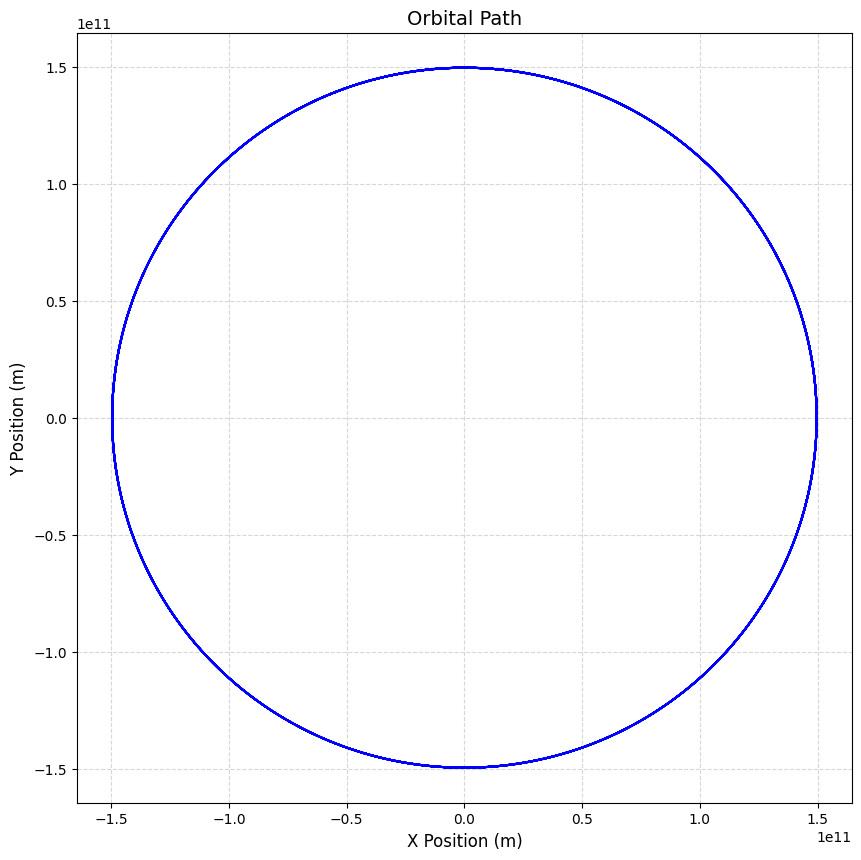

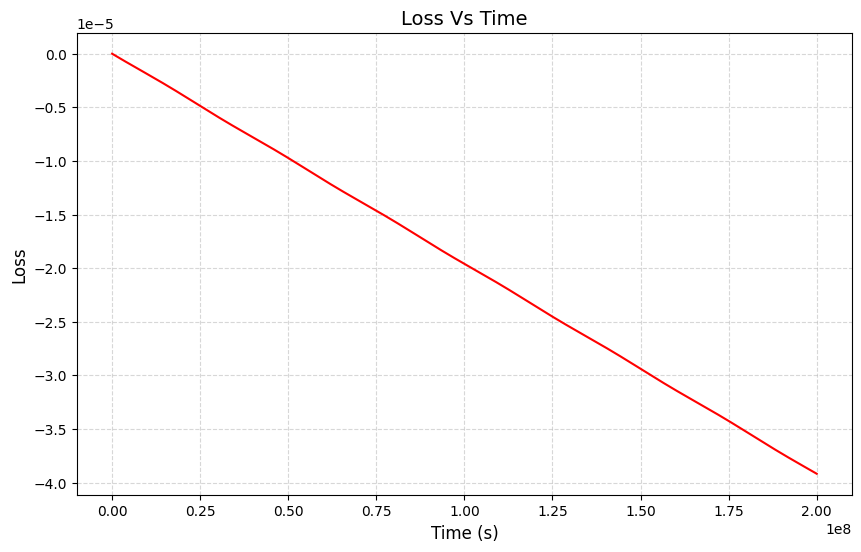

In [19]:
##=============================================================================================##
## Run the Simulation and Get the Sate History:                                                ##
##=============================================================================================##

# Set the time step:

parameters_orbit['dt'] = 1E5

history_orbit = run_simulation(parameters_orbit, initial_state_orbit, cf_euler_richardson_2d, acceleration_orbit)

##=============================================================================================##
## Analyze the Sate History and Get the Simulion Loss:                                         ##
##=============================================================================================##

y_list   = ['Y_Position', 'Loss']
x_list   = ['X_Position', 'Time']
colors   = ['blue', 'red',]
titles   = ['Orbital Path', 'Loss Vs Time']
y_labels = ['Y Position (m)', 'Loss']
x_labels = ['X Position (m)', 'Time (s)']
aspects  = [1.0, 0.6]

loss = analyze_simulation(history_orbit, parameters_orbit, loss_orbit,
                          x_list, y_list, colors, titles, x_labels, y_labels, aspects,
                          plot_data = True, display_data = True)

## <b>Create the Runge-Kutta Method Function</b>

In [20]:
##=============================================================================================##
## Define the Change Function:                                                                 ##
##=============================================================================================##

def cf_runge_kutta_2d(state, parameters, acceleration):

  # Create a local copy of the state object:

  state_local = state.copy()

  # Unpack the parameters:

  G = parameters['G']

  M = parameters['M']

  dt = parameters['dt']

  # Unpack the state:

  x = state_local['X_Position']

  y = state_local['Y_Position']

  vx = state_local['X_Velocity']

  vy = state_local['Y_Velocity']

  # Compute the radial distance to the sun:

  r = np.sqrt(x**2 + y**2)

  # Compute the radial direction:

  rx = x / r

  ry = y / r

  # Compute the acceleration:

  ax, ay = acceleration(state_local, parameters)

  ##===========================================================================================##
  ## Calculate the k1 Values (Slope at the Beginning of the Time Step):                        ##
  ##===========================================================================================##

  k1_x = vx

  k1_y = vy

  k1_vx = ax

  k1_vy = ay

  ##===========================================================================================##
  ## Calculate the k2 Values (Slope at the Midpoint of the Time Step, Based on k1 Values):     ##
  ##===========================================================================================##

  # Position k2 values:

  k2_x = vx + 0.5 * k1_vx * dt

  k2_y = vy + 0.5 * k1_vy * dt

  # Velocity k2 values:

  x_mid_k2 = x + 0.5 * k1_x * dt

  y_mid_k2 = y + 0.5 * k1_y * dt

  # Acceleration k2 values:

  state_local['X_Position'] = x_mid_k2

  state_local['Y_Position'] = y_mid_k2

  k2_vx, k2_vy = acceleration(state_local, parameters)

  ##===========================================================================================##
  ## Calculate the k3 Values (Slope at the Midpoint of the Time Step, Based on k2 Values):     ##
  ##===========================================================================================##

  # Position k3 values:

  k3_x = vx + 0.5 * k2_vx * dt

  k3_y = vy + 0.5 * k2_vy * dt

  # Velocity k3 values:

  x_mid_k3 = x + 0.5 * k2_x * dt

  y_mid_k3 = y + 0.5 * k2_y * dt

  # Acceleration k3 values:

  state_local['X_Position'] = x_mid_k3

  state_local['Y_Position'] = y_mid_k3

  k3_vx, k3_vy = acceleration(state_local, parameters)

  ##===========================================================================================##
  ## Calculate the k4 Values (Slope at the End of the Time Step, Based on k3 Values):          ##
  ##===========================================================================================##

  # Position k4 values:

  k4_x = vx + k3_vx * dt

  k4_y = vy + k3_vy * dt

  # Velocity k4 values:

  x_k4 = x + k3_x * dt

  y_k4 = y + k3_y * dt

  # Acceleration k4 values:

  state_local['X_Position'] = x_k4

  state_local['Y_Position'] = y_k4

  k4_vx, k4_vy = acceleration(state_local, parameters)

  ##===========================================================================================##
  ## Update the State Values:                                                                  ##
  ##===========================================================================================##

  # Update the object's velocity:

  vx += (k1_vx + 2.0 * k2_vx + 2.0 * k3_vx + k4_vx) * dt / 6.0

  vy += (k1_vy + 2.0 * k2_vy + 2.0 * k3_vy + k4_vy) * dt / 6.0

  # Update the object's position:

  x += (k1_x + 2.0 * k2_x + 2.0 * k3_x + k4_x) * dt / 6.0

  y += (k1_y + 2.0 * k2_y + 2.0 * k3_y + k4_y) * dt / 6.0

  # Update the local state positions:

  state_local['X_Position'] = x

  state_local['Y_Position'] = y

  # Update the local state velocity:

  state_local['X_Velocity'] = vx

  state_local['Y_Velocity'] = vy

  # Update the local state time:

  state_local['Time'] += dt

  # Return the updated local state:

  return state_local

## <b>Test the Runge-Kutta Method Function</b>

Elapsed Simulation Runtime: 1.96479 seconds


State History 
 
 
 Time Step 
 X_Position 
 Y_Position 
 X_Velocity 
 Y_Velocity 
 Time 
 Loss 
 
 
 
 
 0 
 1.495979e+11 
 0.000000e+00 
 0.000000 
 29788.620358 
 0.0 
 -0.000000e+00 
 
 
 1 
 1.495682e+11 
 2.978665e+09 
 -593.125597 
 29782.714867 
 100000.0 
 1.731927e-12 
 
 
 2 
 1.494793e+11 
 5.956149e+09 
 -1186.016025 
 29765.000736 
 200000.0 
 3.463317e-12 
 
 
 3 
 1.493310e+11 
 8.931272e+09 
 -1778.436205 
 29735.484988 
 300000.0 
 5.195378e-12 
 
 
 4 
 1.491236e+11 
 1.190285e+10 
 -2370.151247 
 29694.179327 
 400000.0 
 6.926768e-12 
 
 
 5 
 1.488570e+11 
 1.486972e+10 
 -2960.926541 
 29641.100129 
 500000.0 
 8.658427e-12 
 
 
 6 
 1.485314e+11 
 1.783068e+10 
 -3550.527848 
 29576.268440 
 600000.0 
 1.039035e-11 
 
 
 Final State 
 
 
 
 2000 
 
 
 Time Step 
 
 
 
 
 
 X_Position 
 -7.883184e+10 
 
 
 Y_Position 
 1.271419e+11 
 
 
 X_Velocity 
 -2.531708e+04 
 
 
 Y_Velocity 
 -1.569736e+04 
 
 
 Time 
 2.000000e+08 
 
 
 Loss 
 3.463463e-09

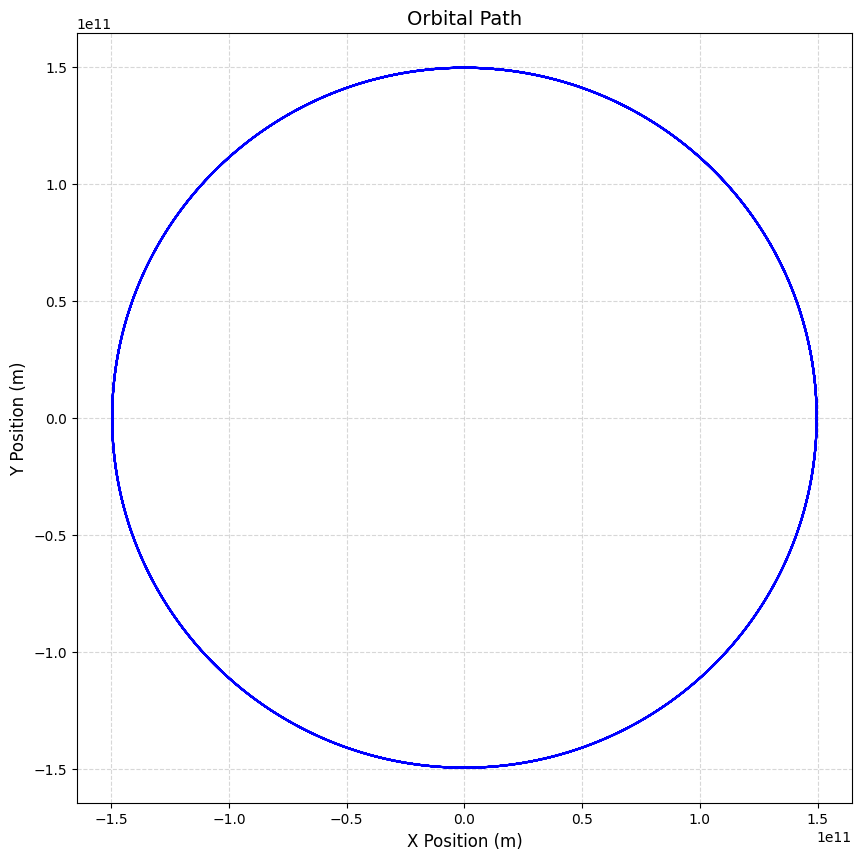

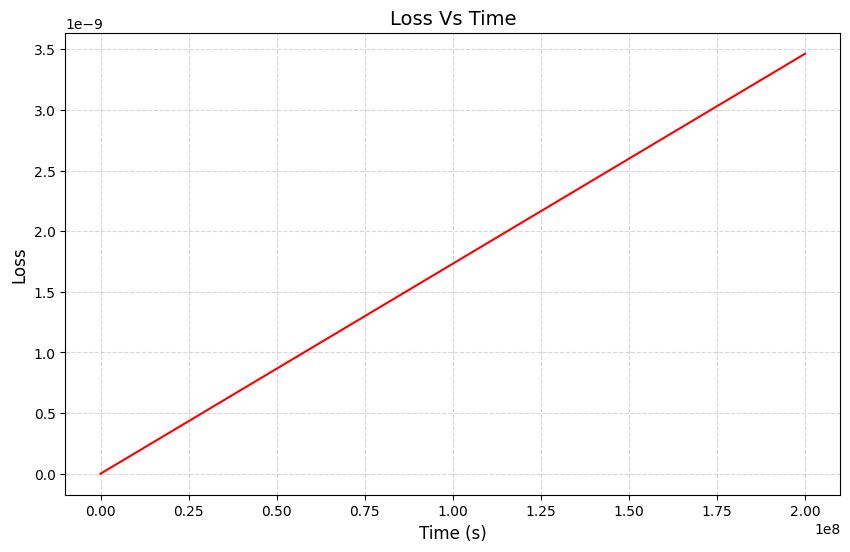

In [21]:
##=============================================================================================##
## Run the Simulation and Get the Sate History:                                                ##
##=============================================================================================##

# Set the time step:

parameters_orbit['dt'] = 1E5

history_orbit = run_simulation(parameters_orbit, initial_state_orbit, cf_runge_kutta_2d, acceleration_orbit)

##=============================================================================================##
## Analyze the Sate History and Get the Simulion Loss:                                         ##
##=============================================================================================##

y_list   = ['Y_Position', 'Loss']
x_list   = ['X_Position', 'Time']
colors   = ['blue', 'red',]
titles   = ['Orbital Path', 'Loss Vs Time']
y_labels = ['Y Position (m)', 'Loss']
x_labels = ['X Position (m)', 'Time (s)']
aspects  = [1.0, 0.6]

loss = analyze_simulation(history_orbit, parameters_orbit, loss_orbit,
                          x_list, y_list, colors, titles, x_labels, y_labels, aspects,
                          plot_data = True, display_data = True)

## <b>Create the Dynamic Time-Step Run Simulation Function</b>

In [37]:
##=============================================================================================##
## Create a Function to Set Up and Run the Simulation:                                         ##
##=============================================================================================##

def run_simulation_dynamic(parameters, initial_state, change_function, acceleration):

  ##===========================================================================================##
  ## Get the Simulation Start Time:                                                            ##
  ##===========================================================================================##

  start_time = tm.time()

  ##===========================================================================================##
  ## Unpack the Simulation Parameters:                                                         ##
  ##===========================================================================================##

  # Get the end time:

  end_time = parameters.loc['t_end']

  # Get the step size:

  dt = parameters.loc['dt']

  # Calculate the number of simulation steps:

  n_steps = int(end_time / dt)

  ##===========================================================================================##
  ## Create a Copy of the Initial State:                                                       ##
  ##===========================================================================================##

  state = initial_state.copy()

  ##===========================================================================================##
  ## Create the System's State History:                                                        ##
  ##===========================================================================================##

  # Create the state_history DataFrame:

  state_history = pd.DataFrame()

  state_history.name = 'Motion Over Time'

  state_history.index.name = 'Time Step'

  # Set the first entry in the state_history to be the initial system state:

  state_history[0] = state

  state_history = state_history.T

  ##===========================================================================================##
  ## Run the Simulation for the Desired Number of Time Steps:                                  ##
  ##===========================================================================================##

  # Set the error tolerance:

  tolerance = 1E-5

  # Set the max number of test iterations:

  max_iterations = 5

  for i in range(n_steps):

    # Set the initial error value:

    error = 1

    # Initialize the test iteration counter:

    iteration = 0

    # Set the starting value of dt:

    dt_test = dt

    while (iteration <= max_iteration):

      parameters_step = parameters.copy()

      # Get the state of the system for the current time step:

      state_test = change_function(state, parameters_step, acceleration)

      # If the error is within the tolerance, end the loop:

      error = loss_orbit(parameters, state_test, state)

      if (np.abs(error) <= tolerance): break

      else: parameters_step['dt'] /= 1.1

      # Increase the iteration counter:

      iteration += 1

      # Check that the max number of iterations hasn't been exceeded:

      if (iteration == max_iterations): print("Max number of iterations exceeded")

    # Store the new system state in the state_history DataFrame:

    state = state_test

    state_history.loc[i + 1] = state.T

    # If an end condition has been reached, break the loop:

    #if (end_condition == True): break

  ##===========================================================================================##
  ## Get the Simulation End Time:                                                              ##
  ##===========================================================================================##

  end_time = tm.time()

  print("Elapsed Simulation Runtime:", np.round(end_time - start_time, 5), "seconds")

  ##===========================================================================================##
  ## Return the System's State History:                                                        ##
  ##===========================================================================================##

  return state_history

## <b>Test the Dynamic Time-Step Function</b>

In [23]:
##=============================================================================================##
## Run the Simulation:                                                                         ##
##=============================================================================================##

# Set the time step:

parameters_orbit['dt'] = 2E6

# Get the simulation start time:

start_time = tm.time()

history = run_simulation(parameters_orbit, initial_state, cf_dynamic_step_orbit)

end_time = tm.time()

print("Simulation Time:", np.round(end_time - start_time, 5), "seconds")

loss = analyze_simulation_orbit(history, parameters_orbit, plot_data = True, display_data = True)

NameError: name 'run_simulation_orbit' is not defined

## <b>Create the New Orbit Parameters</b>

In [ ]:
##=============================================================================================##
## Set the Simulation Parameters:                                                              ##
##=============================================================================================##

# Universal gravitational constant (in N m^2/kg^2):

G = 6.67408e-11

# Mass of the Sun (in kilograms):

M = 1.989e30

# Time step size (in seconds):

dt = 2E6

# Simulation end time (in seconds):

t_end = 2E8

# Error Toleranace:

tolerance = 1E-5

##=============================================================================================##
## Store the parameters in a Pandas Series:                                                    ##
##=============================================================================================##

parameters_dynamic_step = pd.Series({
    "G"    : G,
    "M"    : M,
    "dt"   : dt,
    "t_end": t_end,
    "tolerance": tolerance
})

# Rename the columns:

parameters_dynamic_step.name = 'Value'

parameters_dynamic_step.index.name = "Parameter"

##=============================================================================================##
## Store the initial state in a Pandas Series:                                                 ##
##=============================================================================================##

initial_state_dynamic_step = pd.Series({
    "X_Position": x_initial,
    "Y_Position": y_initial,
    "X_Velocity": vx,
    "Y_Velocity": vy,
    "Time"     : t_initial,
    "dt"       : dt
})

initial_state_dynamic_step.name = 'State'

# Display the Parameters and Initial State:

display_dataframes([parameters, initial_state_dynamic_step],["Parameters", "Initial State"], n_items = 10)

## <b>Update the Dynamic-Step Method Function</b>

In [ ]:
##=============================================================================================##
## Define the Change Function:                                                                 ##
##=============================================================================================##

def cf_dynamic_step_orbit(state, parameters):

  # Create a local copy of the state object:

  state_local = state.copy()

  # Unpack the parameters:

  G = parameters['G']

  M = parameters['M']

  dt = parameters['dt']

  # Unpack the state:

  x = state_local['X_Position']

  y = state_local['Y_Position']

  vx = state_local['X_Velocity']

  vy = state_local['Y_Velocity']

  # Compute the radial distance to the sun:

  r = np.sqrt(x**2 + y**2)

  # Compute the radial direction:

  rx = x / r

  ry = y / r

  # Compute the acceleration:

  ax = -G * M * rx / r**2

  ay = -G * M * ry / r**2

  # Compute the potential energy:

  U = -G * M / r

  # Compute the kinetic energy:

  K = 0.5 * (vx**2 + vy**2)

  # Compute the total energy:

  E = U + K

  ##===========================================================================================##
  ## Perform the Test Step (Euler-Cromer):                                                     ##
  ##===========================================================================================##

  # Set the error tolerance:

  tolerance = parameters['tolerance']

  error = 1

  # Set the max number of test iterations:

  max_iterations = 100

  # Initialize the test iteration counter:

  iteration = 0

  # Set the starting value of dt:

  dt_test = dt

  while (np.abs(error) > tolerance):

    # Update the object's velocity:

    vx_test = vx + ax * dt_test

    vy_test = vy + ay * dt_test

    # Update the object's position:

    x_test = x + vx_test * dt_test

    y_test = y + vy_test * dt_test

    # Compute the radial distance to the sun:

    r_test = np.sqrt(x_test**2 + y_test**2)

    # Compute the potential energy:

    U_test = -G * M / r_test

    # Compute the kinetic energy:

    K_test = 0.5 * (vx_test**2 + vy_test**2)

    # Compute the total energy:

    E_test = U_test + K_test

    # Compute the error:

    error = np.abs(E - E_test) / E

    # If the error is within the tolerance, end the loop:

    if (np.abs(error) <= tolerance): break

    else: dt_test /= 1.1

    # Increase the iteration counter:

    iteration += 1

    # Check that the max number of iterations hasn't been exceeded:

    if (iteration >= max_iterations):

      print("Max number of iterations exceeded")

      break

  ##===========================================================================================##
  ## Update the State Values:                                                                  ##
  ##===========================================================================================##

  # Update the object's velocity:

  vx = vx_test

  vy = vy_test

  # Update the object's position:

  x = x_test

  y = y_test

  # Update the local state positions:

  state_local['X_Position'] = x

  state_local['Y_Position'] = y

  # Update the local state velocity:

  state_local['X_Velocity'] = vx

  state_local['Y_Velocity'] = vy

  # Store the current value of dt:

  state_local['dt'] = dt_test

  # Update the local state time:

  state_local['Time'] += dt_test

  # Return the updated local state:

  return state_local

## <b>Update the Run Simulation Function</b>

In [ ]:
##=============================================================================================##
## Create a Function to Set Up and Run the Simulation:                                         ##
##=============================================================================================##

def run_simulation_dynamic_step(parameters, initial_state, change_function):

  ##===========================================================================================##
  ## Unpack the Simulation Parameters:                                                         ##
  ##===========================================================================================##

  # Set the start time:

  start_time = 0.0

  # Get the end time:

  end_time = parameters.loc['t_end']

  # Get the step size:

  dt = parameters.loc['dt']

  ##===========================================================================================##
  ## Create a Copy of the Initial State:                                                       ##
  ##===========================================================================================##

  state = initial_state.copy()

  ##===========================================================================================##
  ## Create the System's State History:                                                        ##
  ##===========================================================================================##

  # Create the state_history DataFrame:

  state_history = pd.DataFrame()

  state_history.name = 'Motion Over Time'

  state_history.index.name = 'Time Step'

  # Set the first entry in the state_history to be the initial system state:

  state_history[0] = state

  state_history = state_history.T

  ##===========================================================================================##
  ## Run the Simulation for the Desired Number of Time Steps:                                  ##
  ##===========================================================================================##

  while (state['Time'] < end_time):

    # Get the state of the system for the current time step:

    state = change_function(state, parameters)

    # Store the new system state in the state_history DataFrame:

    state_history.loc[len(state_history)] = state.T

  ##===========================================================================================##
  ## Return the System's State History:                                                        ##
  ##===========================================================================================##

  return state_history

## <b>Update the Analyze Simulation Function</b>

In [ ]:
##=============================================================================================##
## Create a Function to Analyze the Simulation Results:                                        ##
##=============================================================================================##

def analyze_simulation_dynamic_step(state_history, parameters, plot_data = False, display_data = False):

  ##===========================================================================================##
  ## Calculate the Initial Total Energy:                                                       ##
  ##===========================================================================================##

  potential_energy_initial = - parameters['G'] * parameters['M'] / np.sqrt(state_history.iloc[0]['X_Position']**2 + state_history.iloc[0]['Y_Position']**2)

  kinetic_energy_initial = 0.5 * state_history.iloc[0]['X_Velocity']**2 + 0.5 * state_history.iloc[0]['Y_Velocity']**2

  total_energy_initial = potential_energy_initial + kinetic_energy_initial

  ##===========================================================================================##
  ## Calculate the Total Energy History:                                                       ##
  ##===========================================================================================##

  potential_energy_history = - parameters['G'] * parameters['M'] / np.sqrt(state_history.iloc[:]['X_Position']**2 + state_history.iloc[:]['Y_Position']**2)

  kinetic_energy_history = 0.5 * state_history.iloc[:]['X_Velocity']**2 + 0.5 * state_history.iloc[:]['Y_Velocity']**2

  total_energy_history = potential_energy_history + kinetic_energy_history

  ##===========================================================================================##
  ## Calculate the Velocity Magnitude History:                                                 ##
  ##===========================================================================================##

  velocity_magnitude = np.sqrt(state_history['X_Velocity']**2 + state_history['Y_Velocity']**2)

  ##===========================================================================================##
  ## Add the Velocity Magnitude History to the State History:                                  ##
  ##===========================================================================================##

  state_history['Velocity'] = velocity_magnitude

  ##===========================================================================================##
  ## Calculate the Loss History:                                                               ##
  ##===========================================================================================##

  loss_history = (total_energy_history - total_energy_initial) / total_energy_initial

  ##===========================================================================================##
  ## Add the Loss History to the State History:                                                ##
  ##===========================================================================================##

  state_history['Loss'] = loss_history

  ##===========================================================================================##
  ## Calculate the Total Loss:                                                                 ##
  ##===========================================================================================##

  total_loss = loss_history.sum()

  ##===========================================================================================##
  ## If requested, display the history data:                                                   ##
  ##===========================================================================================##

  if (display_data == True):

    # View the system's state history and final state:

    display_dataframes([state_history],["State History"])

    print()

    print("Final State:")

    display(state_history.iloc[-1])

    print()

    print("Total Loss:", np.round(total_loss, 5),
          ", Final Loss:", np.round(state_history.iloc[-1]['Loss'], 5))

  ##===========================================================================================##
  ## If requested, plot the history data:                                                      ##
  ##===========================================================================================##

  if (plot_data == True):

    # Create the plot of the Height Data:

    ax1 = state_history.plot(
        kind    = 'line',
        y       = ['Y_Position'],
        x       = 'X_Position',
        color   = ['red'],
        figsize = (10, 10)
    )

    # Create the plot of the Height Data:

    ax2 = state_history.plot(
        kind    = 'line',
        y       = ['Velocity'],
        x       = 'Time',
        color   = ['blue'],
        figsize = (10, 6)
    )

    ax3 = state_history.plot(
        kind    = 'line',
        y       = ['Loss'],
        x       = 'Time',
        color   = ['green'],
        figsize = (10, 6)
    )

    ax4 = state_history.plot(
        kind    = 'line',
        y       = ['dt'],
        x       = 'Time',
        color   = ['red'],
        figsize = (10, 6)
    )

    # Add titles and labels to the plots:

    ax1.set_title("Position", fontsize = 14)
    ax2.set_title("Velocity Vs. Time", fontsize = 14)
    ax3.set_title("Loss Vs. Time", fontsize = 14)
    ax4.set_title("Time Step Vs. Time", fontsize = 14)

    ax1.set_xlabel("X Position (meters)", fontsize = 12)
    ax2.set_xlabel("Seconds", fontsize = 12)
    ax3.set_xlabel("Seconds", fontsize = 12)
    ax4.set_xlabel("Seconds", fontsize = 12)

    ax1.set_ylabel("Y Position (meters)", fontsize = 12)
    ax2.set_ylabel("Velocity (meters/second)", fontsize = 12)
    ax3.set_ylabel("Loss", fontsize = 12)
    ax4.set_ylabel("Time Step (seconds)", fontsize = 12)

    # Add grid and legend:

    ax1.grid(True, linestyle = '--', alpha=0.5)
    ax2.grid(True, linestyle = '--', alpha=0.5)
    ax3.grid(True, linestyle = '--', alpha=0.5)
    ax4.grid(True, linestyle = '--', alpha=0.5)

    legend_1 = ax1.legend()
    legend_2 = ax2.legend()
    legend_3 = ax3.legend()
    legend_4 = ax4.legend()

    legend_1.remove()
    legend_2.remove()
    legend_3.remove()
    legend_4.remove()

    # Display the plots:

    plt.show()

  ##===========================================================================================##
  ## Return the History Data:                                                                  ##
  ##===========================================================================================##

  return state_history.iloc[-1]['Loss']

## <b>Test the New Simulation</b>

In [ ]:
##=============================================================================================##
## Run the Simulation:                                                                         ##
##=============================================================================================##

# Set the time step:

parameters_dynamic_step['dt'] = 2E6

parameters_dynamic_step['tolerance'] = 1E-6

# Get the simulation start time:

start_time = tm.time()

history = run_simulation_dynamic_step(parameters_dynamic_step, initial_state_dynamic_step, cf_dynamic_step_orbit)

end_time = tm.time()

print("Simulation Time:", np.round(end_time - start_time, 5), "seconds")

loss = analyze_simulation_dynamic_step(history, parameters_dynamic_step, plot_data = True, display_data = True)

Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of iterations exceeded
Max number of 

State History 
 
 
 Time Step 
 X_Position 
 Y_Position 
 X_Velocity 
 Y_Velocity 
 Time 
 Loss 
 
 
 
 
 0 
 1.495979e+11 
 0.000000e+00 
 0.000000 
 29788.620358 
 0.0 
 -0.000000 
 
 
 1 
 1.495979e+11 
 5.957724e+10 
 -11863.295897 
 29788.620358 
 2000000.0 
 -0.300529 
 
 
 2 
 1.258713e+11 
 1.191545e+11 
 -21375.993423 
 26000.195645 
 4000000.0 
 -0.550537 
 
 
 3 
 8.311929e+10 
 1.711549e+11 
 -27794.045631 
 19924.626307 
 6000000.0 
 -0.745474 
 
 
 4 
 2.753120e+10 
 2.110041e+11 
 -30997.692597 
 13327.845040 
 8000000.0 
 -0.876960 
 
 
 5 
 -3.446418e+10 
 2.376598e+11 
 -31756.290309 
 7513.814335 
 10000000.0 
 -0.954203 
 
 
 6 
 -9.797677e+10 
 2.526874e+11 
 -31095.597427 
 2957.775910 
 12000000.0 
 -0.995561 
 
 
 Final State 
 
 
 
 100 
 
 
 Time Step 
 
 
 
 
 
 X_Position 
 -2.439388e+12 
 
 
 Y_Position 
 -1.300120e+12 
 
 
 X_Velocity 
 -7.889268e+03 
 
 
 Y_Velocity 
 -7.701540e+03 
 
 
 Time 
 2.000000e+08 
 
 
 Loss 
 -1.028745e+00

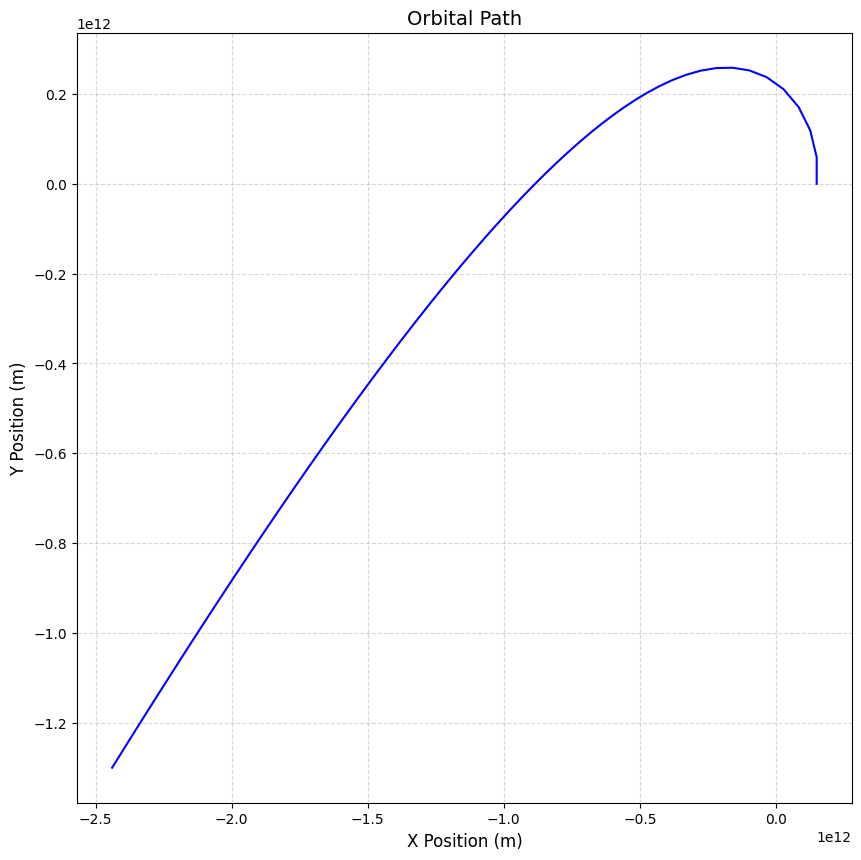

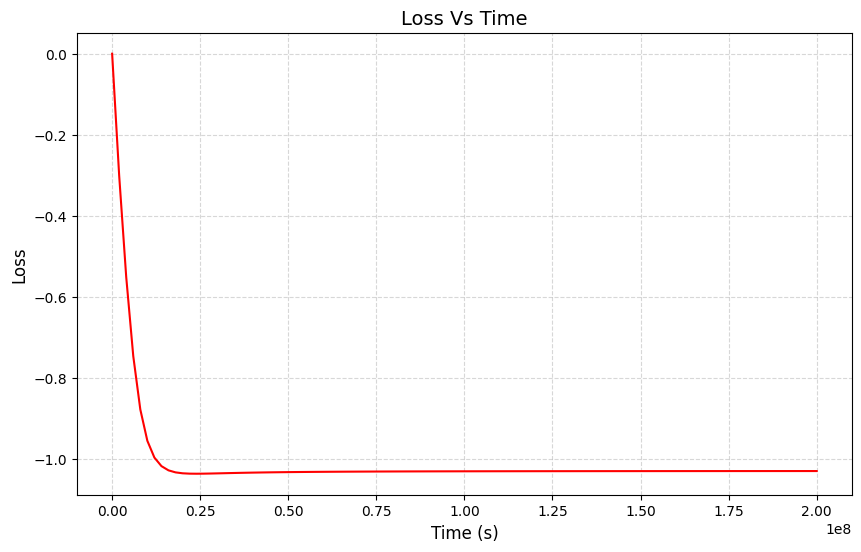

In [38]:
##=============================================================================================##
## Run the Simulation and Get the Sate History:                                                ##
##=============================================================================================##

# Set the time step:

parameters_orbit['dt'] = 2E6

history_orbit = run_simulation_dynamic(parameters_orbit, initial_state_orbit, cf_euler_2d, acceleration_orbit)

##=============================================================================================##
## Analyze the Sate History and Get the Simulion Loss:                                         ##
##=============================================================================================##

y_list   = ['Y_Position', 'Loss']
x_list   = ['X_Position', 'Time']
colors   = ['blue', 'red',]
titles   = ['Orbital Path', 'Loss Vs Time']
y_labels = ['Y Position (m)', 'Loss']
x_labels = ['X Position (m)', 'Time (s)']
aspects  = [1.0, 0.6]

loss = analyze_simulation(history_orbit, parameters_orbit, loss_orbit_history,
                          x_list, y_list, colors, titles, x_labels, y_labels, aspects,
                          plot_data = True, display_data = True)